<a href="https://colab.research.google.com/github/HanaaMaswada/Prediction-of-Product-Sales/blob/main/Project_1(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
import pandas as pd
import numpy as np

In [119]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [120]:
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv')

In [121]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


1) How many rows and columns?

In [123]:
df.shape

(8523, 12)

In [124]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8523
Number of columns: 12


2) What are the datatypes of each variable?

In [125]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


3) Are there duplicates? If so, drop any duplicates.

In [127]:
df.duplicated().sum()

np.int64(0)

4) Identify missing values

In [128]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


5) Address the missing values using a placeholder value

In [129]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(0)

In [130]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

6) Confirm no missing values remain

In [131]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


7) Fix inconsistent categories

In [132]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [133]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

In [134]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

8) Summary statistics (min, max, mean)

In [135]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,10.650590,0.066132,140.992782,1997.831867,2181.288914
std,6.431899,0.051598,62.275067,8.371760,1706.499616
min,0.000000,0.000000,31.290000,1985.000000,33.290000
25%,6.650000,0.026989,93.826500,1987.000000,834.247400
50%,11.000000,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [136]:
df.select_dtypes(include=['int64','float64']).agg(['min','max','mean'])

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,0.00000,0.000000,31.290000,1985.000000,33.290000
max,21.35000,0.328391,266.888400,2009.000000,13086.964800
mean,10.65059,0.066132,140.992782,1997.831867,2181.288914


Project 1 - Part 3

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

##Histogram

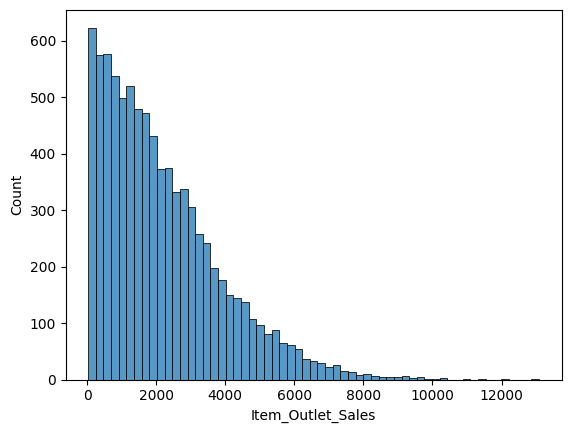

In [138]:
sns.histplot(df['Item_Outlet_Sales'])
plt.show()

##Boxplot

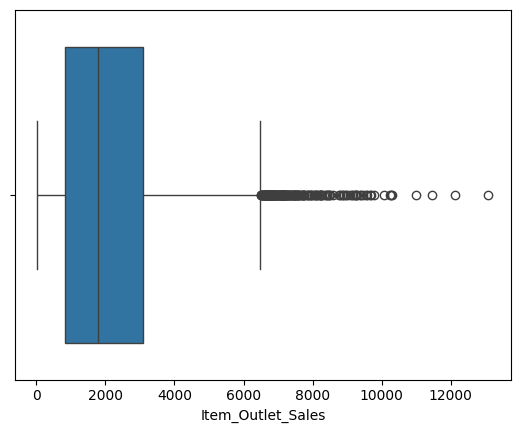

In [139]:
sns.boxplot(x=df['Item_Outlet_Sales'])
plt.show()

##Countplot

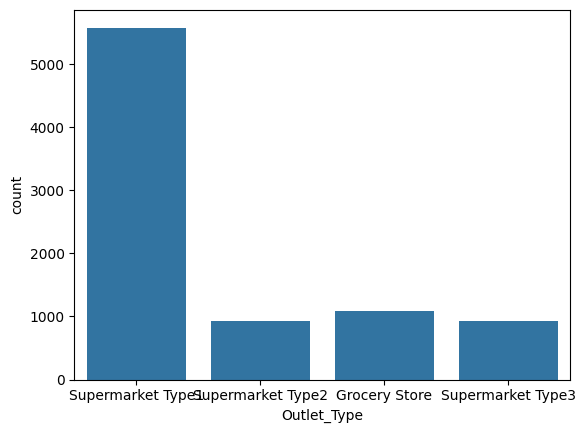

In [140]:
sns.countplot(x=df['Outlet_Type'])
plt.show()

##Heatmap

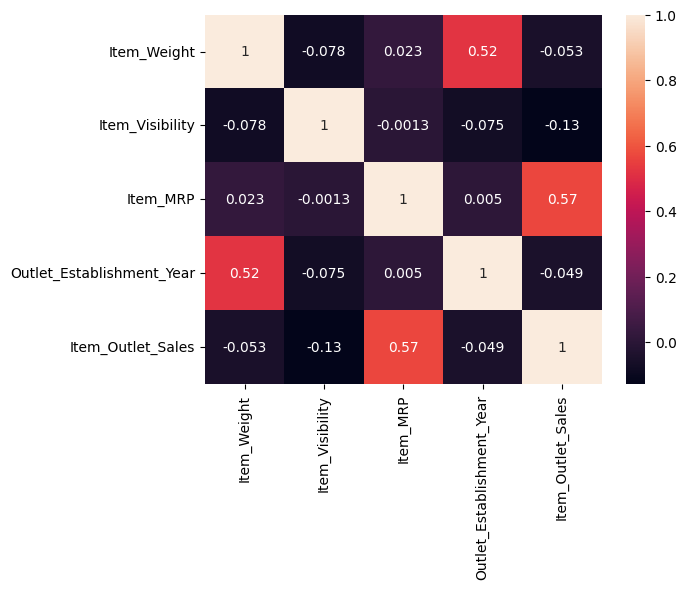

In [141]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True)
plt.show()

## Feature: Item_Weight

Represents the weight of the item.

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

def explore_numeric(df, x):
    fig, axes = plt.subplots(2, 1, figsize=(6,5), sharex=True)

    sns.histplot(data=df, x=x, ax=axes[0])
    sns.boxplot(data=df, x=x, ax=axes[1])

    axes[0].set_title(f"Column: {x}", fontweight='bold')
    plt.tight_layout()
    plt.show()

    null_count = df[x].isna().sum()
    null_perc = null_count / len(df) * 100

    print(f"NaN's Found: {null_count} ({round(null_perc,2)}%)")
    print(f"Unique Values: {df[x].nunique()}")

In [143]:
#numeric vs target
def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales'):
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]

    sns.regplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y} (r = {r})")
    plt.show()

In [144]:
#categorical
def explore_categorical(df, x):
    sns.countplot(data=df, x=x)
    plt.xticks(rotation=45)
    plt.title(f"Column: {x}")
    plt.show()

    print(f"NaN's Found: {df[x].isna().sum()}")
    print(f"Unique Values: {df[x].nunique()}")

In [145]:
#categorical vs target
def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales'):
    sns.barplot(data=df, x=x, y=y)
    plt.xticks(rotation=45)
    plt.title(f"{x} vs {y}")
    plt.show()

In [146]:
df.replace(0, np.nan, inplace=True)
df.replace("Unknown", np.nan, inplace=True)

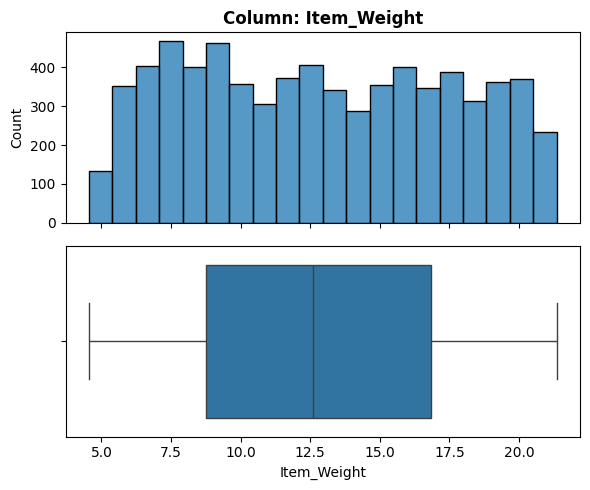

NaN's Found: 1463 (17.17%)
Unique Values: 415


In [147]:
explore_numeric(df, 'Item_Weight')

Outlet_Size

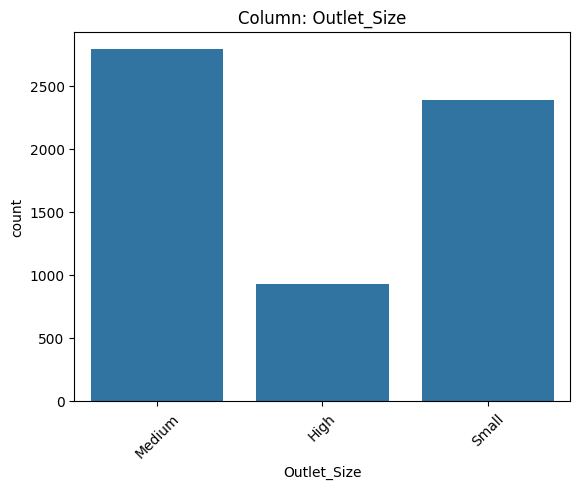

NaN's Found: 2410
Unique Values: 3


In [148]:
explore_categorical(df, 'Outlet_Size')

### Feature Observations:

- Type:
  Categorical

- Null values:
  There are 2410 missing values (~28% of the data).
  Since this is a categorical feature, I would impute the missing values using the most frequent category or keep them as a separate category (e.g., "Missing").

- Constant or quasi-constant:
  No, the values are distributed across three categories.

- Cardinality:
  Low (3 categories: Small, Medium, High)

- Known before target?
  Yes, outlet size is known before sales occur.

- Business reason to exclude?
  No, outlet size is an important factor that can influence sales.

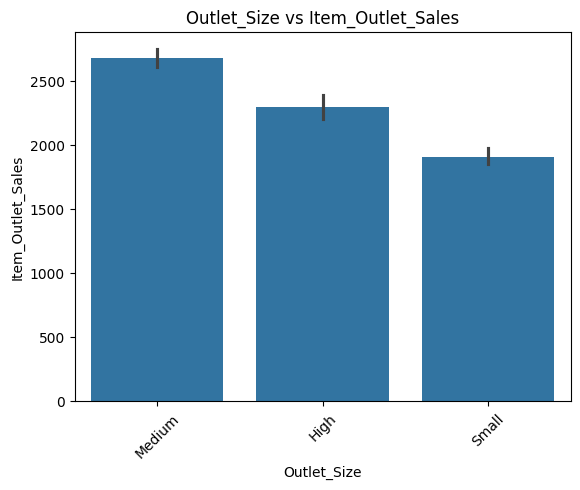

In [149]:
plot_categorical_vs_target(df, 'Outlet_Size', y='Item_Outlet_Sales')

### Feature vs Target Observations:

- Expected to predict target?
  Yes, outlet size is expected to influence sales.

- Does it appear to be a predictor?
  Yes, there is a clear difference in average sales across outlet sizes.

- Explanation:
  Medium outlets have the highest average sales, followed by High, while Small outlets have the lowest sales.
  This indicates that outlet size has a noticeable impact on sales and can be considered a useful predictor.

Item_MRP

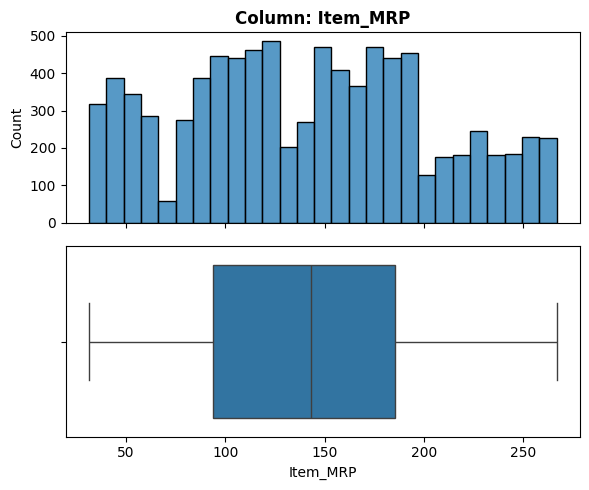

NaN's Found: 0 (0.0%)
Unique Values: 5938


In [150]:
explore_numeric(df, 'Item_MRP')

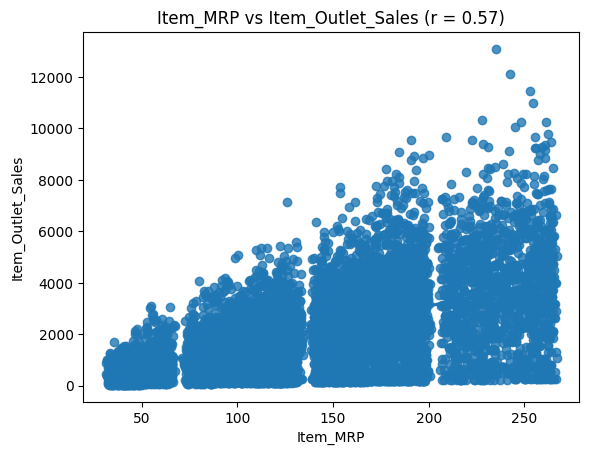

In [151]:
plot_numeric_vs_target(df, 'Item_MRP', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Numeric

- Null values:
  There are no missing values (0%).

- Constant or quasi-constant:
  No, the values are well distributed across a wide range.

- Cardinality:
  High (many unique values: 5938)

- Known before target?
  Yes, the item price is known before sales occur.

- Business reason to exclude?
  No, item price is a key factor that directly affects sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, higher priced items are expected to generate higher sales.

- Does it appear to be a predictor?
  Yes, there is a strong positive relationship.

- Explanation:
  The scatter plot shows a clear upward trend, and the correlation coefficient (r = 0.57) indicates a strong positive relationship.
  This means that as the item price increases, the sales tend to increase as well.
  Therefore, Item_MRP is one of the most important predictors of Item_Outlet_Sales.

Item_MRP appears to be one of the strongest predictors in the dataset and will likely have a significant impact on model performance.

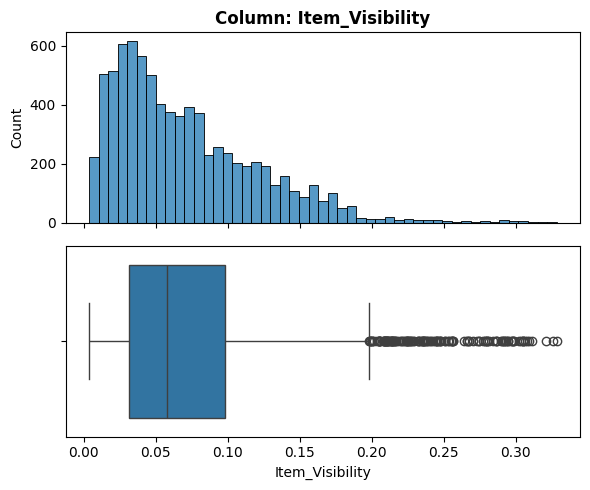

NaN's Found: 526 (6.17%)
Unique Values: 7879


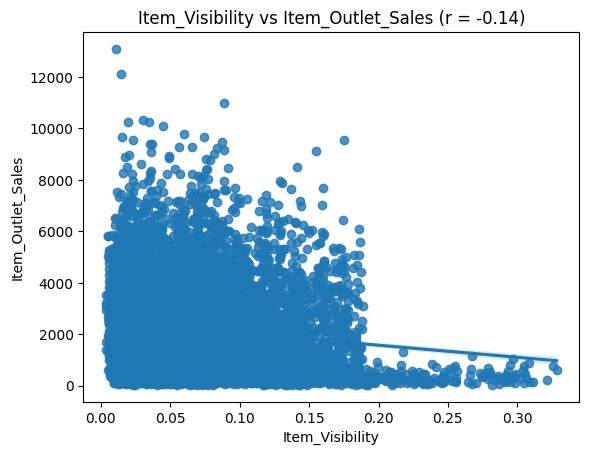

In [152]:
explore_numeric(df, 'Item_Visibility')
plot_numeric_vs_target(df, 'Item_Visibility', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Numeric

- Null values:
  There are 526 missing values (~6.17%).

- Handling null values:
  Instead of dropping rows, we can impute missing values using the median since the data is skewed.

- Constant or quasi-constant:
  No, the feature has a wide distribution of values.

- Cardinality:
  High (many unique values: 7879)

- Known before target?
  Yes, item visibility is determined before sales occur.

- Business reason to exclude?
  No, visibility is an important business factor affecting sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, higher visibility might lead to higher sales.

- Does it appear to be a predictor?
  Weak predictor.

- Explanation:
  The scatter plot shows a very weak negative relationship (r = -0.14).
  This suggests that higher visibility does not strongly increase sales and may even slightly decrease it.
  The data is highly scattered with no clear trend, indicating low predictive power.

Item_Visibility may have limited impact on the model and might require feature engineering or transformation to improve its usefulness.

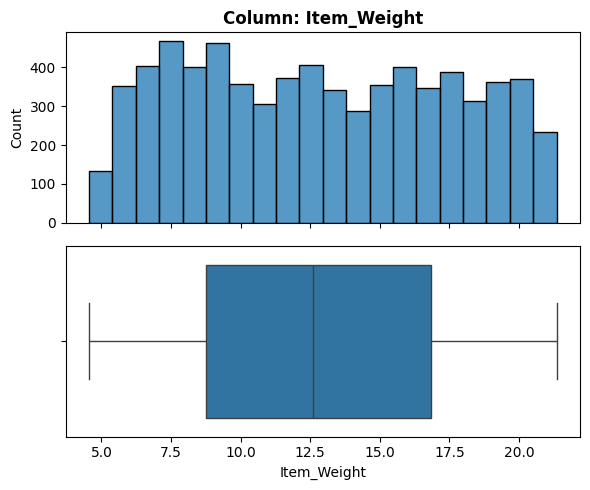

NaN's Found: 1463 (17.17%)
Unique Values: 415


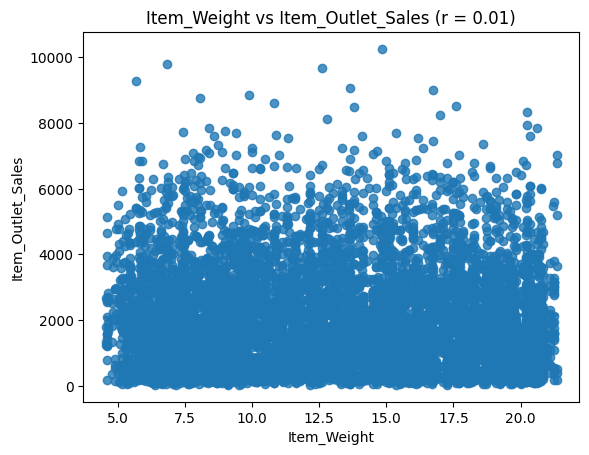

In [153]:
explore_numeric(df, 'Item_Weight')
plot_numeric_vs_target(df, 'Item_Weight', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Numeric

- Null values:
  There are 1463 missing values (~17.17%).

- Handling null values:
  We should impute missing values using the median because the distribution is fairly spread and median is robust to outliers.

- Constant or quasi-constant:
  No, the feature has a wide range of values.

- Cardinality:
  Moderate (415 unique values)

- Known before target?
  Yes, item weight is known before sales occur.

- Business reason to exclude?
  No, weight could influence packaging, pricing, and logistics, so it may indirectly affect sales.

### Feature vs Target Observations:

- Expected to predict target?
  Possibly, but not strongly.

- Does it appear to be a predictor?
  No, very weak predictor.

- Explanation:
  The scatter plot shows almost no relationship between Item_Weight and Item_Outlet_Sales (r = 0.01).
  The data points are randomly scattered with no visible pattern, indicating no correlation.

Item_Weight does not show a meaningful relationship with sales and may not contribute significantly to the predictive model.

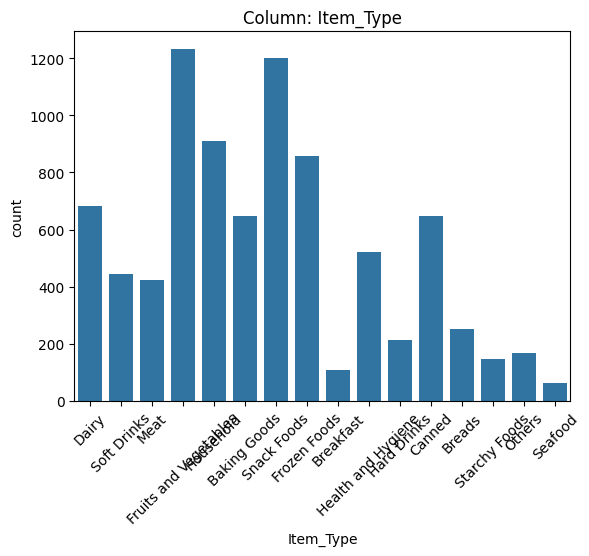

NaN's Found: 0
Unique Values: 16


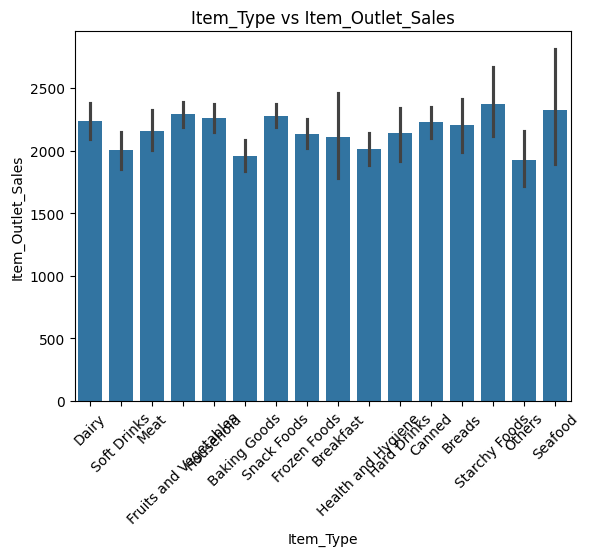

In [154]:
explore_categorical(df, 'Item_Type')
plot_categorical_vs_target(df, 'Item_Type', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Categorical (Nominal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, the feature contains multiple categories with varied distribution.

- Cardinality:
  Moderate (16 unique categories)

- Known before target?
  Yes, item type is known before sales occur.

- Business reason to exclude?
  No, product category is an important factor that influences customer demand and sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, different product categories are expected to have different sales patterns.

- Does it appear to be a predictor?
  Yes, moderate predictor.

- Explanation:
  The bar plot shows variation in average sales across different item types.
  Some categories like Seafood and Starchy Foods appear to have higher sales,
  while others like Breakfast and Baking Goods have relatively lower sales.
  This indicates that Item_Type has a noticeable impact on Item_Outlet_Sales.

Item_Type is a meaningful feature and should definitely be included in the model as it captures consumer preferences across product categories.

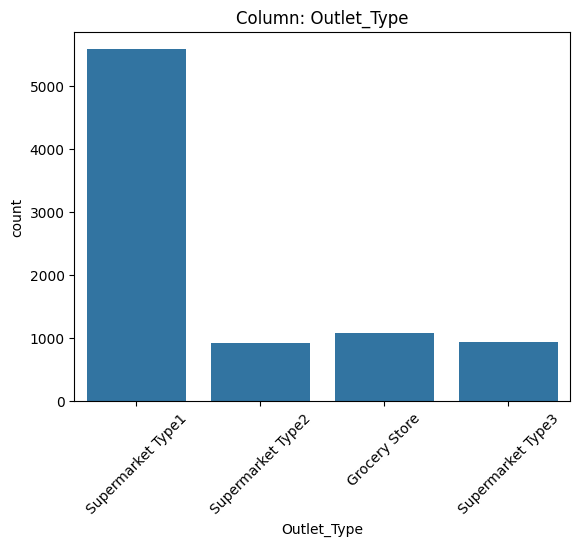

NaN's Found: 0
Unique Values: 4


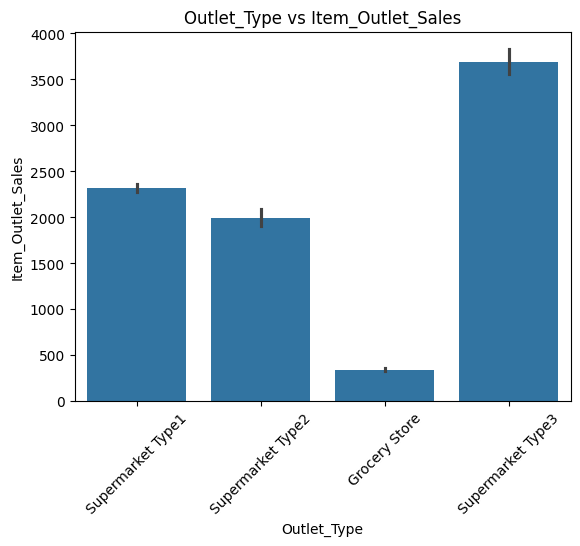

In [155]:
# Univariate
explore_categorical(df, 'Outlet_Type')

# Multivariate
plot_categorical_vs_target(df, 'Outlet_Type', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Categorical (Nominal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, there are multiple categories with different frequencies.

- Cardinality:
  Low (4 unique values)

- Known before target?
  Yes, outlet type is known before sales occur.

- Business reason to exclude?
  No, outlet type is an important factor that affects sales performance.

### Feature Observations:

- Type:
  Categorical (Nominal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, there are multiple categories with different frequencies.

- Cardinality:
  Low (4 unique values)

- Known before target?
  Yes, outlet type is known before sales occur.

- Business reason to exclude?
  No, outlet type is an important factor that affects sales performance.

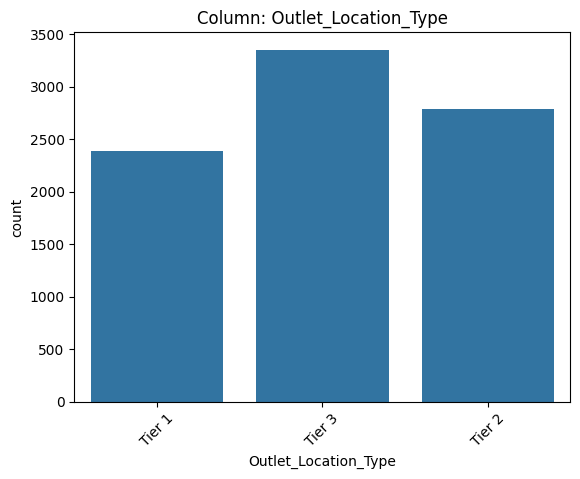

NaN's Found: 0
Unique Values: 3


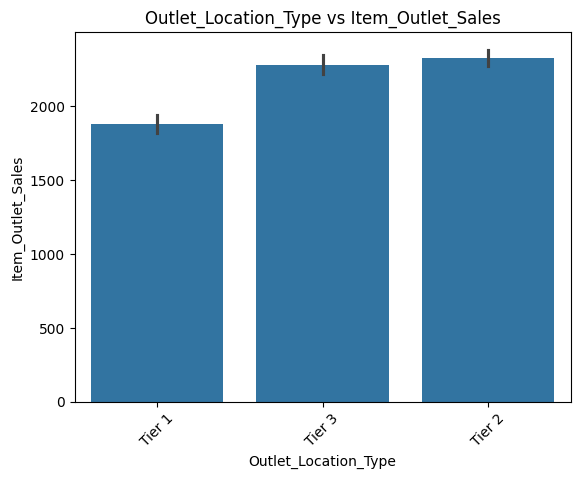

In [156]:
explore_categorical(df, 'Outlet_Location_Type')
plot_categorical_vs_target(df, 'Outlet_Location_Type', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Categorical (Ordinal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, there are multiple categories with balanced distribution.

- Cardinality:
  Low (3 unique values: Tier 1, Tier 2, Tier 3)

- Known before target?
  Yes, outlet location is known before sales occur.

- Business reason to exclude?
  No, location type is an important factor influencing customer behavior and sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, different location tiers are expected to affect sales.

- Does it appear to be a predictor?
  Yes, moderate predictor.

- Explanation:
  The plot shows that Tier 2 and Tier 3 locations have higher average sales compared to Tier 1.
  This indicates that location plays a role in sales performance.
  However, the difference between Tier 2 and Tier 3 is not very large, suggesting a moderate impact.

Outlet_Location_Type has a noticeable effect on sales and should be included as a feature in the model.

Project 1 - Part 5

In [157]:
import pandas as pd
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

In [158]:
# set output as pandas
set_config(transform_output="pandas")

In [159]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,NaN,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,NaN,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


CLEANING BEFORE SPLIT

In [160]:
# remove duplicates
df = df.drop_duplicates()

# fix inconsistent categories
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# drop high-cardinality column
df = df.drop(columns='Item_Identifier')



DEFINE X AND y

In [161]:
y = df['Item_Outlet_Sales']
X = df.drop(columns='Item_Outlet_Sales')

TRAIN TEST SPLIT

In [162]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)


DEFINE COLUMN TYPES

In [163]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns


CREATE PIPELINES

In [164]:
# numeric pipeline
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# categorical pipeline
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)


CREATE COLUMN TRANSFORMER

In [165]:
col_transformer = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ],
    verbose_feature_names_out=False
)


FIT ON TRAINING DATA

In [166]:
col_transformer.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                  verbose_feature_names_out=False)

TRANSFORM DATA

In [167]:
X_train_processed = col_transformer.transform(X_train)
X_test_processed = col_transformer.transform(X_test)


CHECK RESULTS

In [168]:
# check datatypes (should be all numeric)
print(X_train_processed.dtypes)

# check scaling (mean ≈ 0, std ≈ 1)
print(X_train_processed.describe())

# preview data
print(X_train_processed.head())
print(X_test_processed.head())

Item_Weight                        float64
Item_Visibility                    float64
Item_MRP                           float64
Outlet_Establishment_Year          float64
Item_Fat_Content_Low Fat           float64
Item_Fat_Content_Regular           float64
Item_Type_Baking Goods             float64
Item_Type_Breads                   float64
Item_Type_Breakfast                float64
Item_Type_Canned                   float64
Item_Type_Dairy                    float64
Item_Type_Frozen Foods             float64
Item_Type_Fruits and Vegetables    float64
Item_Type_Hard Drinks              float64
Item_Type_Health and Hygiene       float64
Item_Type_Household                float64
Item_Type_Meat                     float64
Item_Type_Others                   float64
Item_Type_Seafood                  float64
Item_Type_Snack Foods              float64
Item_Type_Soft Drinks              float64
Item_Type_Starchy Foods            float64
Outlet_Identifier_OUT010           float64
Outlet_Iden

In [169]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(model, X_train, y_train, X_test, y_test):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    def print_metrics(y_true, y_pred, name):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        r2 = r2_score(y_true, y_pred)

        print(f"--- {name} ---")
        print(f"MAE: {mae:.3f}")
        print(f"MSE: {mse:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"R2: {r2:.3f}")
        print()

    print_metrics(y_train, y_train_pred, "Train")
    print_metrics(y_test, y_test_pred, "Test")

In [170]:
[name for name in globals() if 'lin' in name.lower() or 'reg' in name.lower()]

['make_pipeline', 'evaluate_regression', 'LinearRegression', 'linreg_pipe']

In [171]:
[name for name in globals() if 'pre' in name.lower() or 'processor' in name.lower() or 'transformer' in name.lower()]

['ColumnTransformer', 'col_transformer']

In [172]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Create and train Linear Regression model
linreg_pipe = make_pipeline(col_transformer, LinearRegression())

linreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [173]:
evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test)

--- Train ---
MAE: 847.248
MSE: 1297761.268
RMSE: 1139.193
R2: 0.561

--- Test ---
MAE: 803.820
MSE: 1194033.039
RMSE: 1092.718
R2: 0.567



The Linear Regression model achieved an R² score of approximately 0.56 on both the training and test sets.
The similarity between the training and test performance indicates that the model does not suffer from overfitting.
However, the relatively low R² value suggests that the model is underfitting, meaning it is too simple to capture the underlying patterns in the data.
Therefore, Linear Regression is not the most suitable model for this problem, and a more complex model is needed to improve performance.

In [176]:
# 2) Default Random Forest Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# Build default Random Forest model inside a pipeline
rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(col_transformer, rf)

# Fit the model on training data
rf_pipe.fit(X_train, y_train)

# Evaluate the model on training and test data
print("Random Forest Results:")
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

# Get R2 values directly
y_train_pred_rf = rf_pipe.predict(X_train)
y_test_pred_rf = rf_pipe.predict(X_test)

rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

print("Random Forest R2 Comparison:")
print(f"Train R2: {rf_train_r2:.3f}")
print(f"Test R2 : {rf_test_r2:.3f}")

# Compare with Linear Regression
y_train_pred_lr = linreg_pipe.predict(X_train)
y_test_pred_lr = linreg_pipe.predict(X_test)

lr_train_r2 = r2_score(y_train, y_train_pred_lr)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)

print("\nModel Comparison:")
print(f"Linear Regression Test R2 : {lr_test_r2:.3f}")
print(f"Random Forest Test R2    : {rf_test_r2:.3f}")

if rf_test_r2 > lr_test_r2:
    print("Random Forest has the better test score.")
else:
    print("Linear Regression has the better test score.")

Random Forest Results:
--- Train ---
MAE: 296.737
MSE: 184345.442
RMSE: 429.355
R2: 0.938

--- Test ---
MAE: 767.526
MSE: 1220152.119
RMSE: 1104.605
R2: 0.558

Random Forest R2 Comparison:
Train R2: 0.938
Test R2 : 0.558

Model Comparison:
Linear Regression Test R2 : 0.567
Random Forest Test R2    : 0.558
Linear Regression has the better test score.


##Random Forest Model

The Random Forest model achieved a very high R² score on the training set (0.938) but a much lower R² score on the test set (0.558).
This large gap between training and test performance indicates that the model is overfitting, meaning it is learning the training data too well but does not generalize effectively to unseen data.

When comparing with the Linear Regression model, Random Forest did not improve performance, as Linear Regression achieved a slightly higher test R² (0.567 vs 0.558).
Therefore, in this case, Linear Regression performed better on the test data, making it the more suitable model among the two.

In [178]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# Random Forest pipeline
rf_pipe = make_pipeline(
    col_transformer,
    RandomForestRegressor(random_state=42)
)

# Tune at least two hyperparameters
param_grid = {
    'randomforestregressor__n_estimators': [100, 200],
    'randomforestregressor__max_depth': [None, 10, 20],
    'randomforestregressor__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters:
{'randomforestregressor__max_depth': 10, 'randomforestregressor__min_samples_leaf': 4, 'randomforestregressor__n_estimators': 100}


In [179]:
# Best tuned model
best_rf = grid_search.best_estimator_

print("Tuned Random Forest Results:")
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

Tuned Random Forest Results:
--- Train ---
MAE: 661.329
MSE: 888976.728
RMSE: 942.856
R2: 0.700

--- Test ---
MAE: 732.757
MSE: 1112579.754
RMSE: 1054.789
R2: 0.597



In [180]:
# Predictions for comparison
y_test_pred_default_rf = rf_pipe.fit(X_train, y_train).predict(X_test)
y_test_pred_best_rf = best_rf.predict(X_test)

default_rf_test_r2 = r2_score(y_test, y_test_pred_default_rf)
best_rf_test_r2 = r2_score(y_test, y_test_pred_best_rf)

print("Comparison of Test R2:")
print(f"Default Random Forest Test R2: {default_rf_test_r2:.3f}")
print(f"Tuned Random Forest Test R2  : {best_rf_test_r2:.3f}")

if best_rf_test_r2 > default_rf_test_r2:
    print("The tuned Random Forest improved performance.")
elif best_rf_test_r2 < default_rf_test_r2:
    print("The tuned Random Forest did not improve performance.")
else:
    print("The tuned Random Forest performed the same as the default model.")

Comparison of Test R2:
Default Random Forest Test R2: 0.558
Tuned Random Forest Test R2  : 0.597
The tuned Random Forest improved performance.


After applying GridSearchCV, the best hyperparameters for the Random Forest model were found to be a maximum depth of 10, a minimum of 4 samples per leaf, and 100 estimators.

The tuned model achieved an R² score of 0.597 on the test set, compared to 0.558 for the default Random Forest model. This indicates that hyperparameter tuning successfully improved the model’s generalization performance.

Additionally, the gap between training (R² = 0.700) and test performance (R² = 0.597) is smaller than before, which suggests that overfitting has been reduced.

Therefore, the tuned Random Forest model is better than the default Random Forest and provides improved predictions on unseen data.

The best model is the tuned Random Forest model because it achieved the highest R² score on the test set.

##CRISP-DM Phase 5 – Evaluation

###Recommended Model

Based on the evaluation of multiple models, the tuned Random Forest model is recommended for deployment, as it achieved the highest R² score on the test set compared to Linear Regression and the default Random Forest model.

###Justification

The tuned Random Forest model achieved an R² score of approximately 0.597, which is higher than Linear Regression (0.567) and the default Random Forest (0.558).
This indicates that it provides better predictive performance on unseen data and captures more complex patterns in the dataset.

###Explain R² for Non-Technical Stakeholders

The R² value shows how well the model can explain the variation in sales.
In this case, an R² of 0.597 means that the model explains about 60% of the variation in sales, while the remaining 40% is due to other factors not captured by the model.
This indicates a moderate level of prediction accuracy.

###Additional Metric (RMSE)

In addition to R², we use RMSE (Root Mean Squared Error) to measure model performance.
RMSE represents the average prediction error in the same units as the target variable (sales).
For the tuned Random Forest model, the RMSE on the test set is approximately 1054.8, meaning that predictions are off by about 1055 units on average.

###Why RMSE?

RMSE is useful because it provides an intuitive understanding of prediction error in real-world units, making it easier for stakeholders to interpret how far predictions are from actual values.

###Overfitting / Underfitting Analysis

The tuned Random Forest model shows some difference between training (R² ≈ 0.700) and testing performance (R² ≈ 0.597), which indicates slight overfitting.
However, the gap is smaller than in the default Random Forest model, meaning that tuning helped improve generalization.
Overall, the model balances bias and variance better than the other models.

## part 8

###1) Linear Regression coefficients

In [181]:
# Get feature names and coefficients from Linear Regression
feature_names = linreg_pipe.named_steps['columntransformer'].get_feature_names_out()
coefs = linreg_pipe.named_steps['linearregression'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
38,Outlet_Type_Grocery Store,-1097.910820,1097.910820
2,Item_MRP,984.494108,984.494108
41,Outlet_Type_Supermarket Type3,711.632225,711.632225
27,Outlet_Identifier_OUT027,711.632225,711.632225
22,Outlet_Identifier_OUT010,-642.067078,642.067078
26,Outlet_Identifier_OUT019,-455.843742,455.843742
39,Outlet_Type_Supermarket Type1,337.607847,337.607847
18,Item_Type_Seafood,309.758981,309.758981
28,Outlet_Identifier_OUT035,221.675110,221.675110
29,Outlet_Identifier_OUT045,-180.542544,180.542544


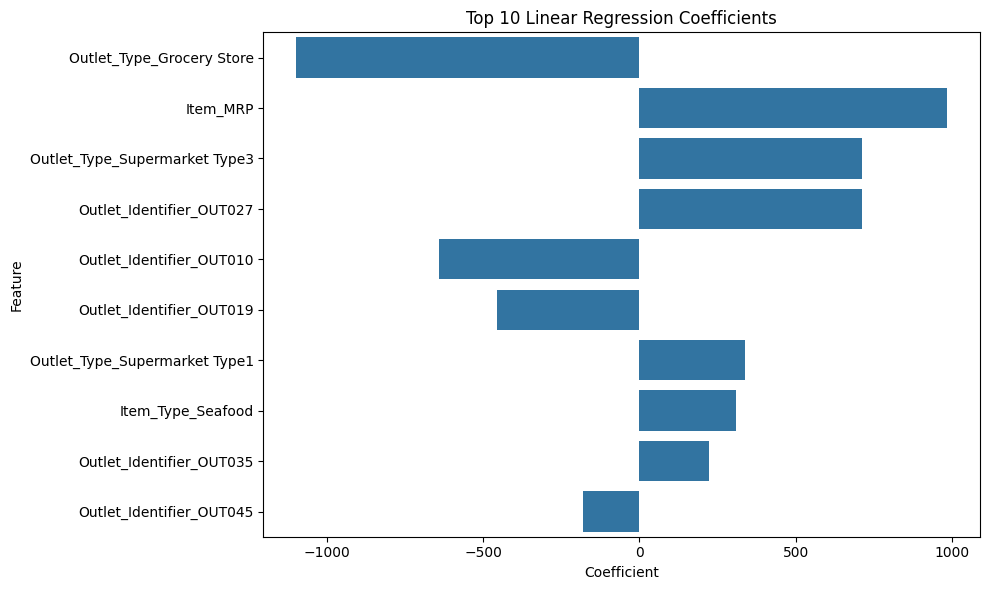

In [182]:
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature')
plt.title('Top 10 Linear Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('linear_regression_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

###2) Random Forest feature importance

In [183]:
# Get feature names and feature importances from best Random Forest
feature_names = best_rf.named_steps['columntransformer'].get_feature_names_out()
importances = best_rf.named_steps['randomforestregressor'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
2,Item_MRP,0.519453
38,Outlet_Type_Grocery Store,0.269359
41,Outlet_Type_Supermarket Type3,0.046038
1,Item_Visibility,0.043185
27,Outlet_Identifier_OUT027,0.043015
3,Outlet_Establishment_Year,0.024981
0,Item_Weight,0.019415
12,Item_Type_Fruits and Vegetables,0.003098
19,Item_Type_Snack Foods,0.002281
15,Item_Type_Household,0.002042


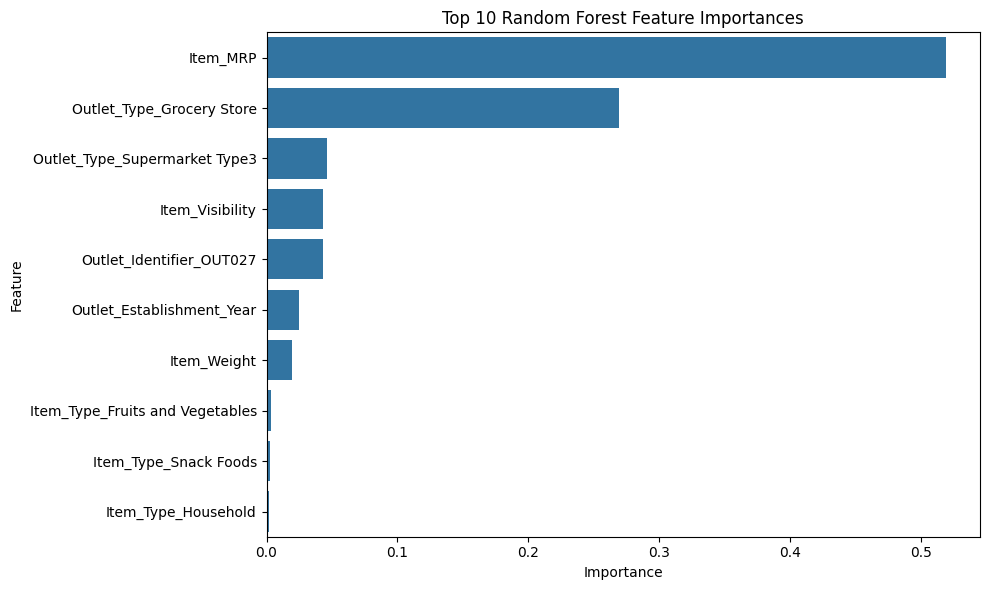

In [184]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()